# Word2Vec: Mathematics and Implementation from Scratch

**Deep Learning Course**

In this notebook, we dive into the mathematical foundations of Word2Vec and implement the **Skip-gram model from scratch** using only NumPy.

We'll cover:

1. Mathematical foundations (one-hot vectors, dot product, softmax)
2. Skip-gram objective function and gradient derivation
3. Data preparation for training
4. Complete Skip-gram implementation from scratch
5. Training and evaluating the model

## 2.1 Mathematical Foundations

### One-Hot Vectors as Matrix Lookups

A one-hot vector serves as an **index selector** for a row in a weight matrix:

$$
\mathbf{x} = \begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \end{bmatrix}, \quad
W = \begin{bmatrix} w_{11} & w_{12} \\ w_{21} & w_{22} \\ w_{31} & w_{32} \\ w_{41} & w_{42} \end{bmatrix}
$$

The matrix multiplication $\mathbf{x}^T W$ simply **selects the 3rd row**:

$$
\mathbf{x}^T W = \begin{bmatrix} 0 & 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} w_{11} & w_{12} \\ w_{21} & w_{22} \\ w_{31} & w_{32} \\ w_{41} & w_{42} \end{bmatrix} = \begin{bmatrix} w_{31} & w_{32} \end{bmatrix}
$$

In [1]:
import numpy as np

# Demonstrate one-hot as row selector
x = np.array([0, 0, 1, 0])
W = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])

print("One-hot vector x:", x)
print("Weight matrix W:")
print(W)
print("\nx @ W (selects 3rd row):", x @ W)
print("Direct access W[2]:", W[2])

One-hot vector x: [0 0 1 0]
Weight matrix W:
[[1 2]
 [3 4]
 [5 6]
 [7 8]]

x @ W (selects 3rd row): [5 6]
Direct access W[2]: [5 6]


**Key Insight**: In Word2Vec, the embedding layer is essentially a lookup table. The "multiplication" by a one-hot vector is just selecting a row—this is why it's so efficient!

### Dot Product and Similarity

The dot product measures the **alignment** between two vectors:

$$
\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^{n} u_i v_i = \|\mathbf{u}\| \|\mathbf{v}\| \cos(\theta)
$$

Where $\theta$ is the angle between the vectors.

In [2]:
def dot_product(u, v):
    return np.sum(u * v)

def cosine_similarity(u, v):
    """Normalized dot product - ranges from -1 to 1"""
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u == 0 or norm_v == 0:
        return 0
    return dot_product(u, v) / (norm_u * norm_v)

# Example
v1 = np.array([1, 0])
v2 = np.array([1, 1])
v3 = np.array([-1, 0])

print(f"v1 = {v1}, v2 = {v2}, v3 = {v3}")
print(f"dot(v1, v2) = {dot_product(v1, v2):.2f}  (positive = same direction)")
print(f"dot(v1, v3) = {dot_product(v1, v3):.2f}  (negative = opposite direction)")
print(f"cosine(v1, v2) = {cosine_similarity(v1, v2):.4f}")
print(f"cosine(v1, v3) = {cosine_similarity(v1, v3):.4f}")

v1 = [1 0], v2 = [1 1], v3 = [-1  0]
dot(v1, v2) = 1.00  (positive = same direction)
dot(v1, v3) = -1.00  (negative = opposite direction)
cosine(v1, v2) = 0.7071
cosine(v1, v3) = -1.0000


### Softmax Function

Softmax converts a vector of scores into a **probability distribution**:

$$
\text{softmax}(\mathbf{y})_i = \frac{e^{y_i}}{\sum_{j=1}^{K} e^{y_j}}
$$

In [3]:
def softmax(y, temperature=1.0):
    """Compute softmax with optional temperature scaling."""
    y_scaled = y / temperature
    exp_y = np.exp(y_scaled - np.max(y_scaled))  # Numerical stability
    return exp_y / np.sum(exp_y)

# Example
scores = np.array([4.0, 2.5, 1.0])
probs = softmax(scores)

print("Raw scores:", scores)
print("Softmax probabilities:", probs)
print("Sum of probabilities:", np.sum(probs))

# Effect of temperature
print("\nEffect of temperature on [4.0, 2.0, 1.0]:")
for t in [0.5, 1.0, 2.0, 5.0]:
    p = softmax(np.array([4.0, 2.0, 1.0]), temperature=t)
    print(f"  T={t}: {p}")

Raw scores: [4.  2.5 1. ]
Softmax probabilities: [0.78559703 0.17529039 0.03911257]
Sum of probabilities: 1.0

Effect of temperature on [4.0, 2.0, 1.0]:
  T=0.5: [0.97962921 0.01794253 0.00242826]
  T=1.0: [0.84379473 0.1141952  0.04201007]
  T=2.0: [0.62853172 0.2312239  0.14024438]
  T=5.0: [0.45062671 0.30206411 0.24730918]


**Note**: Lower temperature → sharper distribution (more confident). Higher temperature → flatter distribution (less confident).

---
## 2.2 Skip-gram Model: Objective Function and Gradients

### Problem Formulation

Given a corpus of $T$ words, the Skip-gram model maximizes the probability of context words given a center word.

**Notation**:
- $w_t$: word at position $t$ in the corpus
- $m$: window size (number of context words on each side)
- $V$: vocabulary size
- $d$: embedding dimension

### The Objective Function

For a single center word $w_t$ and a single context word $w_{t+j}$ (where $-m \leq j \leq m$, $j \neq 0$):

$$
P(w_{t+j} | w_t) = \frac{\exp(\mathbf{u}_{w_{t+j}}^T \mathbf{v}_{w_t})}{\sum_{k=1}^{V} \exp(\mathbf{u}_k^T \mathbf{v}_{w_t})}
$$

Where:
- $\mathbf{v}_{w_t} \in \mathbb{R}^d$: **center word embedding** (input embedding)
- $\mathbf{u}_{w_{t+j}} \in \mathbb{R}^d$: **context word embedding** (output embedding)
- $\mathbf{u}_k$: embedding for the $k$-th word in vocabulary (as context)

**The full objective** (average negative log-likelihood):

$$
J(\theta) = -\frac{1}{T} \sum_{t=1}^{T} \sum_{\substack{-m \leq j \leq m \\ j \neq 0}} \log P(w_{t+j} | w_t)
$$

### Understanding the Architecture

```
         ┌─────────────────────────────────────┐
         │  One-hot input: w_t (center word)   │
         │  Dimension: V (vocabulary size)      │
         └─────────────────┬───────────────────┘
                           │
                           ▼
         ┌─────────────────────────────────────┐
         │  Input Embedding Matrix W₁         │
         │  Shape: V × d                       │
         │  (Each row is a center word vector) │
         └─────────────────┬───────────────────┘
                           │
                           ▼
         ┌─────────────────────────────────────┐
         │  Hidden representation: v_{w_t}     │
         │  Dimension: d (e.g., 100-300)       │
         └─────────────────┬───────────────────┘
                           │
                           ▼
         ┌─────────────────────────────────────┐
         │  Output Embedding Matrix W₂        │
         │  Shape: d × V                       │
         │  (Each column is a context vector)  │
         └─────────────────┬───────────────────┘
                           │
                           ▼
         ┌─────────────────────────────────────┐
         │  Score vector: u_k^T · v_{w_t}     │
         │  Dimension: V                       │
         └─────────────────┬───────────────────┘
                           │
                           ▼
         ┌─────────────────────────────────────┐
         │  Softmax → Probability distribution │
         │  Dimension: V                       │
         └─────────────────────────────────────┘
```

### Computing the Gradient

For a single training pair (center word $c$, context word $o$), the loss is:

$$
L = -\log P(o | c) = -\mathbf{u}_o^T \mathbf{v}_c + \log \sum_{k=1}^{V} \exp(\mathbf{u}_k^T \mathbf{v}_c)
$$

**Gradient with respect to $\mathbf{v}_c$ (center word embedding)**:

$$
\frac{\partial L}{\partial \mathbf{v}_c} = -\mathbf{u}_o + \sum_{k=1}^{V} P(k|c) \mathbf{u}_k
$$

This can be written as:

$$
\frac{\partial L}{\partial \mathbf{v}_c} = \underbrace{(\text{predicted distribution})}_{\hat{\mathbf{y}}} \cdot \underbrace{W_2}_{\text{context embeddings}} - \underbrace{\mathbf{u}_o}_{\text{true context}}
$$

**Gradient with respect to $\mathbf{u}_k$ (context word embedding)**:

$$
\frac{\partial L}{\partial \mathbf{u}_k} = (P(k|c) - \mathbb{1}[k=o]) \mathbf{v}_c
$$

Where $\mathbb{1}[k=o]$ is 1 if $k$ is the true context word, 0 otherwise.

In [4]:
def compute_gradients(v_c, U, o_idx):
    """
    Compute gradients for Skip-gram.
    
    Args:
        v_c: Center word embedding (d,)
        U: Context embedding matrix (V, d)
        o_idx: Index of true context word
    
    Returns:
        grad_v_c: Gradient for center embedding (d,)
        grad_U: Gradient for context embeddings (V, d)
    """
    V, d = U.shape
    
    # Compute scores
    scores = U @ v_c  # (V,)
    
    # Compute softmax probabilities
    probs = softmax(scores)  # (V,)
    
    # Gradient for v_c: -u_o + sum_k P(k|c) * u_k
    grad_v_c = -U[o_idx] + probs @ U  # (d,)
    
    # Gradient for U: (P(k|c) - 1[k=o]) * v_c
    grad_U = np.outer(probs, v_c)  # (V, d)
    grad_U[o_idx] -= v_c  # Subtract v_c for the true context word
    
    return grad_v_c, grad_U

# Example with small dimensions
np.random.seed(42)
V, d = 5, 3

# Random embeddings
v_c = np.random.randn(d)
U = np.random.randn(V, d)
o_idx = 2  # True context word index

grad_v_c, grad_U = compute_gradients(v_c, U, o_idx)

print(f"Center embedding v_c: {v_c}")
print(f"Context matrix U shape: {U.shape}")
print(f"True context word index: {o_idx}")
print(f"\nGradient for v_c: {grad_v_c}")
print(f"Gradient for U shape: {grad_U.shape}")

Center embedding v_c: [ 0.49671415 -0.1382643   0.64768854]
Context matrix U shape: (5, 3)
True context word index: 2

Gradient for v_c: [0.34411793 0.15870118 0.11123075]
Gradient for U shape: (5, 3)


### The Computational Problem: Full Softmax

The issue with the standard softmax is that we must compute $\exp(\mathbf{u}_k^T \mathbf{v}_c)$ for **all** $V$ words in the vocabulary.

For $V = 100,000$ words:
- Each forward pass: 100,000 dot products
- Each backward pass: 100,000 gradient updates

This is extremely slow!

**Solutions in practice**:
1. **Negative Sampling**: Approximate softmax by only computing for a few "negative" samples
2. **Hierarchical Softmax**: Use a binary tree structure

For educational purposes, we'll implement the **full softmax version** to understand the fundamentals.

---
## 2.3 Implementation from Scratch: Data Preparation

In [5]:
import numpy as np
from collections import Counter
import re
import random

# ============================================
# STEP 1: CORPUS PREPARATION
# ============================================

def load_and_preprocess(text):
    """Load and preprocess text corpus."""
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Split into words
    words = text.split()
    
    return words

# Example corpus (in practice, use a much larger corpus)
corpus_text = """
The king sat on his throne. The queen sat beside the king. 
The prince and princess played in the garden. The royal family 
lived in a beautiful castle. The king ruled the kingdom wisely.
The queen was loved by all the people. The prince learned to 
become a great ruler. The princess danced at the royal ball.
The kingdom prospered under the king and queen. The castle 
stood tall on the hill overlooking the kingdom.
"""

words = load_and_preprocess(corpus_text)
print(f"Corpus size: {len(words)} words")
print(f"First 20 words: {words[:20]}")

Corpus size: 75 words
First 20 words: ['the', 'king', 'sat', 'on', 'his', 'throne', 'the', 'queen', 'sat', 'beside', 'the', 'king', 'the', 'prince', 'and', 'princess', 'played', 'in', 'the', 'garden']


In [6]:
# ============================================
# STEP 2: BUILD VOCABULARY
# ============================================

def build_vocabulary(words, min_count=1):
    """Build vocabulary with word-to-index mappings."""
    # Count word frequencies
    word_counts = Counter(words)
    
    # Filter by minimum count
    filtered_words = [w for w in words if word_counts[w] >= min_count]
    
    # Create vocabulary (sorted by frequency for consistency)
    vocab = sorted(set(filtered_words), 
                   key=lambda w: (-word_counts[w], w))
    
    # Create mappings
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    return vocab, word2idx, idx2word, word_counts

vocab, word2idx, idx2word, word_counts = build_vocabulary(words, min_count=1)

print(f"\nVocabulary size: {len(vocab)}")
print(f"Word-to-index mapping (first 10):")
for word in list(word2idx.keys())[:10]:
    print(f"  '{word}': {word2idx[word]}")


Vocabulary size: 42
Word-to-index mapping (first 10):
  'the': 0
  'king': 1
  'kingdom': 2
  'queen': 3
  'a': 4
  'and': 5
  'castle': 6
  'in': 7
  'on': 8
  'prince': 9


In [7]:
# ============================================
# STEP 3: GENERATE TRAINING DATA FOR SKIP-GRAM
# ============================================

def generate_skipgram_data(words, word2idx, window_size=2):
    """
    Generate (center_word, context_word) pairs for Skip-gram.
    
    Args:
        words: List of words in the corpus
        word2idx: Word to index mapping
        window_size: Number of context words on each side
    
    Returns:
        pairs: List of (center_idx, context_idx) tuples
    """
    pairs = []
    
    for i, center_word in enumerate(words):
        center_idx = word2idx[center_word]
        
        # Define context window
        start = max(0, i - window_size)
        end = min(len(words), i + window_size + 1)
        
        for j in range(start, end):
            if i != j:  # Skip the center word itself
                context_word = words[j]
                context_idx = word2idx[context_word]
                pairs.append((center_idx, context_idx))
    
    return pairs

# Generate training pairs
window_size = 2
training_pairs = generate_skipgram_data(words, word2idx, window_size)

print(f"\nTraining pairs generated: {len(training_pairs)}")
print(f"\nFirst 15 training pairs (center → context):")
for center_idx, context_idx in training_pairs[:15]:
    center_word = idx2word[center_idx]
    context_word = idx2word[context_idx]
    print(f"  '{center_word}' → '{context_word}'")


Training pairs generated: 294

First 15 training pairs (center → context):
  'the' → 'king'
  'the' → 'sat'
  'king' → 'the'
  'king' → 'sat'
  'king' → 'on'
  'sat' → 'the'
  'sat' → 'king'
  'sat' → 'on'
  'sat' → 'his'
  'on' → 'king'
  'on' → 'sat'
  'on' → 'his'
  'on' → 'throne'
  'his' → 'sat'
  'his' → 'on'


In [8]:
# ============================================
# STEP 4: VISUALIZE THE WINDOW SLIDING
# ============================================

def visualize_windows(words, window_size=2, num_examples=3):
    """Visualize how the sliding window generates training pairs."""
    print(f"\nVisualizing Skip-gram Window (size={window_size}):")
    print("=" * 60)
    
    for start_idx in range(min(num_examples, len(words) - 2*window_size)):
        center_pos = start_idx + window_size
        center_word = words[center_pos]
        
        print(f"\nSentence segment: ...", end=" ")
        for i in range(start_idx, min(center_pos + window_size + 1, len(words))):
            if i == center_pos:
                print(f"[{words[i]}]", end=" ")
            else:
                print(words[i], end=" ")
        print("...")
        
        print(f"Center word: '{center_word}'")
        print(f"Context words: ", end="")
        for j in range(max(0, center_pos - window_size), 
                       min(len(words), center_pos + window_size + 1)):
            if j != center_pos:
                print(f"'{words[j]}' ", end="")
        print()

visualize_windows(words, window_size=2, num_examples=3)


Visualizing Skip-gram Window (size=2):

Sentence segment: ... the king [sat] on his ...
Center word: 'sat'
Context words: 'the' 'king' 'on' 'his' 

Sentence segment: ... king sat [on] his throne ...
Center word: 'on'
Context words: 'king' 'sat' 'his' 'throne' 

Sentence segment: ... sat on [his] throne the ...
Center word: 'his'
Context words: 'sat' 'on' 'throne' 'the' 


### Using a Larger Corpus for Better Results

For meaningful embeddings, we need a larger corpus. Let's use a sample from Alice in Wonderland:

In [9]:
# For a real implementation, download a larger corpus
alice_text = """
Alice was beginning to get very tired of sitting by her sister on the bank 
and of having nothing to do once or twice she had peeped into the book her 
sister was reading but it had no pictures or conversations in it and what is 
the use of a book thought Alice without pictures or conversations So she was 
considering in her own mind as well as she could for the hot day made her feel 
very sleepy and stupid whether the pleasure of making a daisy chain would be 
worth the trouble of getting up and picking the daisies when suddenly a White 
Rabbit with pink eyes ran close by her There was nothing so very remarkable in 
that nor did Alice think it so very much out of the way to hear the Rabbit say 
to itself Oh dear Oh dear I shall be late When she thought it over afterwards 
it occurred to her that she ought to have wondered at this but at the time it 
all seemed quite natural But when the Rabbit actually took a watch out of its 
waistcoat pocket and looked at it and then hurried on Alice started to her feet 
for it flashed across her mind that she had never before seen a rabbit with 
either a waistcoat pocket or a watch to take out of it and burning with curiosity 
she ran across the field after it and fortunately was just in time to see it pop 
down a large rabbit hole under the hedge In another moment down went Alice after 
it never once considering how in the world she was to get out again The rabbit 
hole went straight on like a tunnel for some way and then dipped suddenly down 
so suddenly that Alice had not a moment to think about stopping herself before 
she found herself falling down a very deep well Either the well was very deep 
or she fell very slowly for she had plenty of time as she went down to look 
about her and to wonder what was going to happen next First she tried to look 
down and make out what she was coming to but it was too dark to see anything 
then she looked at the sides of the well and noticed that they were filled with 
cupboards and book shelves here and there she saw maps and pictures hung upon 
pegs She took down a jar from one of the shelves as she passed it was labelled 
ORANGE MARMALADE but to her great disappointment it was empty she did not like 
to drop the jar for fear of killing somebody underneath so managed to put it 
into one of the cupboards as she fell past it
"""

# Process the larger corpus
words = load_and_preprocess(alice_text)
vocab, word2idx, idx2word, word_counts = build_vocabulary(words, min_count=2)
training_pairs = generate_skipgram_data(words, word2idx, window_size=2)

print(f"Corpus size: {len(words)} words")
print(f"Vocabulary size (min_count=2): {len(vocab)} words")
print(f"Training pairs: {len(training_pairs)}")
print(f"\nTop 10 most frequent words:")
for word, count in word_counts.most_common(10):
    print(f"  '{word}': {count}")

KeyError: 'beginning'

---
## 2.4 Implementation from Scratch: Model Building and Training

### The Skip-gram Model Class

In [10]:
class SkipGramModel:
    """
    Skip-gram Word2Vec implementation from scratch.
    
    Architecture:
        Input (one-hot) → Center Embedding (W1) → Output Scores (W2) → Softmax
    """
    
    def __init__(self, vocab_size, embedding_dim, seed=42):
        """
        Initialize the Skip-gram model.
        
        Args:
            vocab_size: Size of vocabulary (V)
            embedding_dim: Dimension of word embeddings (d)
            seed: Random seed for reproducibility
        """
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # Initialize weight matrices
        np.random.seed(seed)
        
        # W1: Center word embeddings (V × d)
        # Each row is the embedding for a word when it's the CENTER word
        self.W1 = np.random.randn(vocab_size, embedding_dim) * 0.01
        
        # W2: Context word embeddings (V × d)  
        # Each row is the embedding for a word when it's a CONTEXT word
        self.W2 = np.random.randn(vocab_size, embedding_dim) * 0.01
        
        # For tracking training
        self.loss_history = []
    
    def forward(self, center_idx):
        """
        Forward pass: compute probability distribution over vocabulary.
        
        Args:
            center_idx: Index of center word
            
        Returns:
            probs: Probability distribution (V,)
            h: Hidden representation (d,)
        """
        # Get center word embedding (this is essentially a lookup)
        h = self.W1[center_idx]  # (d,)
        
        # Compute scores: dot product with all context embeddings
        scores = self.W2 @ h  # (V,)
        
        # Apply softmax to get probabilities
        probs = self._softmax(scores)
        
        return probs, h
    
    def _softmax(self, x):
        """Numerically stable softmax."""
        x_shifted = x - np.max(x)
        exp_x = np.exp(x_shifted)
        return exp_x / np.sum(exp_x)
    
    def compute_loss(self, center_idx, context_idx):
        """
        Compute negative log-likelihood loss.
        
        Args:
            center_idx: Index of center word
            context_idx: Index of true context word
            
        Returns:
            loss: Negative log-likelihood (scalar)
        """
        probs, _ = self.forward(center_idx)
        # Avoid log(0) by clipping
        loss = -np.log(probs[context_idx] + 1e-10)
        return loss
    
    def backward(self, center_idx, context_idx, h, probs, learning_rate):
        """
        Backward pass: compute gradients and update weights.
        
        Args:
            center_idx: Index of center word
            context_idx: Index of true context word
            h: Hidden representation from forward pass
            probs: Probability distribution from forward pass
            learning_rate: Learning rate for gradient descent
        """
        # Create error vector: predicted - true (one-hot)
        # e_i = P(i|c) - 1 if i is context word, else P(i|c)
        e = probs.copy()
        e[context_idx] -= 1  # Subtract 1 for the true context word
        
        # Gradient for W2 (context embeddings)
        # dW2[i] = e[i] * h
        grad_W2 = np.outer(e, h)  # (V, d)
        
        # Gradient for W1 (center embedding)
        # dW1[c] = W2^T @ e
        grad_W1_center = self.W2.T @ e  # (d,)
        
        # Update weights
        self.W2 -= learning_rate * grad_W2
        self.W1[center_idx] -= learning_rate * grad_W1_center
    
    def train(self, training_pairs, epochs=10, learning_rate=0.01, 
              verbose=True, print_every=100):
        """
        Train the Skip-gram model.
        
        Args:
            training_pairs: List of (center_idx, context_idx) tuples
            epochs: Number of training epochs
            learning_rate: Learning rate
            verbose: Whether to print progress
            print_every: Print loss every N samples
        """
        n_samples = len(training_pairs)
        
        for epoch in range(epochs):
            # Shuffle training pairs each epoch
            random.shuffle(training_pairs)
            
            epoch_loss = 0
            
            for i, (center_idx, context_idx) in enumerate(training_pairs):
                # Forward pass
                probs, h = self.forward(center_idx)
                
                # Compute loss
                loss = -np.log(probs[context_idx] + 1e-10)
                epoch_loss += loss
                
                # Backward pass
                self.backward(center_idx, context_idx, h, probs, learning_rate)
                
                # Print progress
                if verbose and (i + 1) % print_every == 0:
                    avg_loss = epoch_loss / (i + 1)
                    print(f"Epoch {epoch+1}/{epochs}, Step {i+1}/{n_samples}, "
                          f"Avg Loss: {avg_loss:.4f}")
            
            # Record average loss for this epoch
            avg_epoch_loss = epoch_loss / n_samples
            self.loss_history.append(avg_epoch_loss)
            
            if verbose:
                print(f"\nEpoch {epoch+1} completed. Average Loss: {avg_epoch_loss:.4f}\n")
    
    def get_center_embedding(self, word, word2idx):
        """Get the center word embedding for a word."""
        if word not in word2idx:
            raise ValueError(f"'{word}' not in vocabulary")
        idx = word2idx[word]
        return self.W1[idx]
    
    def get_context_embedding(self, word, word2idx):
        """Get the context word embedding for a word."""
        if word not in word2idx:
            raise ValueError(f"'{word}' not in vocabulary")
        idx = word2idx[word]
        return self.W2[idx]
    
    def get_embedding(self, word, word2idx, combine='center'):
        """
        Get word embedding (can combine center and context embeddings).
        
        Args:
            word: The word to get embedding for
            word2idx: Word to index mapping
            combine: 'center', 'context', or 'average'
        """
        if combine == 'center':
            return self.get_center_embedding(word, word2idx)
        elif combine == 'context':
            return self.get_context_embedding(word, word2idx)
        elif combine == 'average':
            v = self.get_center_embedding(word, word2idx)
            u = self.get_context_embedding(word, word2idx)
            return (v + u) / 2
        else:
            raise ValueError(f"Unknown combine method: {combine}")
    
    def most_similar(self, word, word2idx, idx2word, topn=10, combine='average'):
        """Find most similar words to a given word."""
        if word not in word2idx:
            raise ValueError(f"'{word}' not in vocabulary")
        
        # Get embedding for query word
        query_vec = self.get_embedding(word, word2idx, combine=combine)
        query_norm = np.linalg.norm(query_vec)
        
        # Compute similarities with all words
        similarities = []
        for idx in range(self.vocab_size):
            if idx2word[idx] == word:
                continue  # Skip the query word itself
            
            # Get embedding for this word
            if combine == 'center':
                vec = self.W1[idx]
            elif combine == 'context':
                vec = self.W2[idx]
            else:
                vec = (self.W1[idx] + self.W2[idx]) / 2
            
            vec_norm = np.linalg.norm(vec)
            
            # Cosine similarity
            if query_norm > 0 and vec_norm > 0:
                sim = np.dot(query_vec, vec) / (query_norm * vec_norm)
            else:
                sim = 0
            
            similarities.append((idx2word[idx], sim))
        
        # Sort by similarity (descending)
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        return similarities[:topn]
    
    def analogy(self, word_a, word_b, word_c, word2idx, idx2word, 
                topn=5, combine='average'):
        """
        Solve analogy: word_a is to word_b as word_c is to ?
        Mathematically: ? = word_b - word_a + word_c
        """
        vec_a = self.get_embedding(word_a, word2idx, combine)
        vec_b = self.get_embedding(word_b, word2idx, combine)
        vec_c = self.get_embedding(word_c, word2idx, combine)
        
        # Compute target vector
        target_vec = vec_b - vec_a + vec_c
        target_norm = np.linalg.norm(target_vec)
        
        # Find closest words
        exclude = {word_a, word_b, word_c}
        similarities = []
        
        for idx in range(self.vocab_size):
            word = idx2word[idx]
            if word in exclude:
                continue
            
            if combine == 'center':
                vec = self.W1[idx]
            elif combine == 'context':
                vec = self.W2[idx]
            else:
                vec = (self.W1[idx] + self.W2[idx]) / 2
            
            vec_norm = np.linalg.norm(vec)
            
            if target_norm > 0 and vec_norm > 0:
                sim = np.dot(target_vec, vec) / (target_norm * vec_norm)
            else:
                sim = 0
            
            similarities.append((word, sim))
        
        similarities.sort(key=lambda x: x[1], reverse=True)
        return similarities[:topn]

print("SkipGramModel class defined successfully!")

SkipGramModel class defined successfully!


### Training the Model

In [11]:
# ============================================
# TRAIN THE SKIP-GRAM MODEL
# ============================================

# Model parameters
embedding_dim = 50
learning_rate = 0.025
epochs = 100
window_size = 2

print("="*60)
print("SKIP-GRAM TRAINING")
print("="*60)
print(f"Vocabulary size: {len(vocab)}")
print(f"Embedding dimension: {embedding_dim}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Training pairs: {len(training_pairs)}")
print("="*60)

# Initialize model
model = SkipGramModel(vocab_size=len(vocab), embedding_dim=embedding_dim)

# Train
model.train(training_pairs, epochs=epochs, learning_rate=learning_rate, 
            verbose=True, print_every=200)

SKIP-GRAM TRAINING
Vocabulary size: 76
Embedding dimension: 50
Learning rate: 0.025
Epochs: 100
Training pairs: 294
Epoch 1/100, Step 200/294, Avg Loss: 4.3307

Epoch 1 completed. Average Loss: 4.3307

Epoch 2/100, Step 200/294, Avg Loss: 4.3304

Epoch 2 completed. Average Loss: 4.3304

Epoch 3/100, Step 200/294, Avg Loss: 4.3300

Epoch 3 completed. Average Loss: 4.3299

Epoch 4/100, Step 200/294, Avg Loss: 4.3292

Epoch 4 completed. Average Loss: 4.3291

Epoch 5/100, Step 200/294, Avg Loss: 4.3277

Epoch 5 completed. Average Loss: 4.3276

Epoch 6/100, Step 200/294, Avg Loss: 4.3252

Epoch 6 completed. Average Loss: 4.3247

Epoch 7/100, Step 200/294, Avg Loss: 4.3209

Epoch 7 completed. Average Loss: 4.3189

Epoch 8/100, Step 200/294, Avg Loss: 4.3079

Epoch 8 completed. Average Loss: 4.3072

Epoch 9/100, Step 200/294, Avg Loss: 4.2859

Epoch 9 completed. Average Loss: 4.2841

Epoch 10/100, Step 200/294, Avg Loss: 4.2439

Epoch 10 completed. Average Loss: 4.2405

Epoch 11/100, Step 200

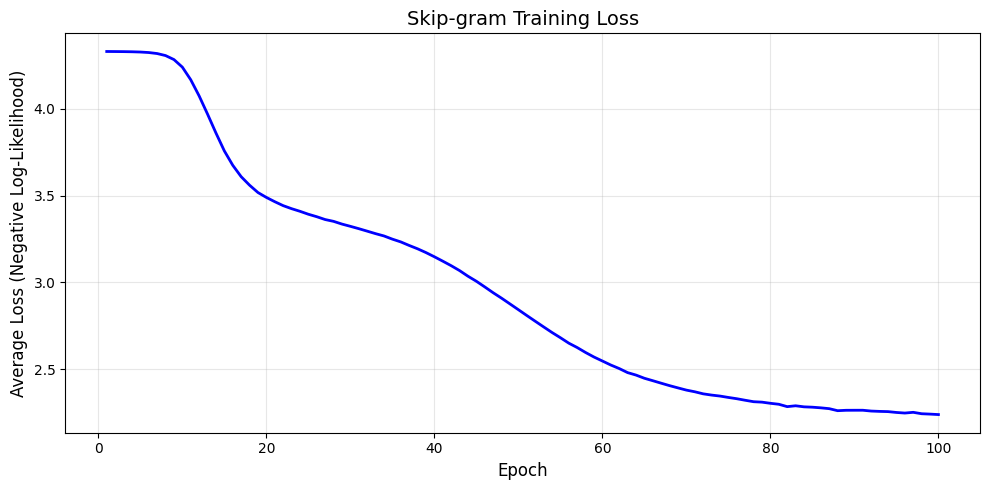

In [12]:
# ============================================
# PLOT TRAINING LOSS
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), model.loss_history, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss (Negative Log-Likelihood)', fontsize=12)
plt.title('Skip-gram Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluating the Trained Embeddings

In [13]:
# ============================================
# EVALUATE WORD SIMILARITIES
# ============================================

print("="*60)
print("WORD SIMILARITIES")
print("="*60)

test_words = ['she', 'rabbit', 'down', 'very', 'was']

for word in test_words:
    if word in word2idx:
        similar = model.most_similar(word, word2idx, idx2word, topn=5)
        print(f"\nWords similar to '{word}':")
        for w, sim in similar:
            print(f"  {w:15} {sim:.4f}")
    else:
        print(f"\n'{word}' not in vocabulary")

WORD SIMILARITIES

Words similar to 'she':
  or              0.9364
  in              0.8669
  it              0.8667
  when            0.8205
  of              0.7800

Words similar to 'rabbit':
  out             0.9535
  time            0.8861
  considering     0.8756
  suddenly        0.8727
  it              0.5566

Words similar to 'down':
  on              0.8501
  of              0.8351
  time            0.7850
  before          0.6946
  very            0.6645

Words similar to 'very':
  went            0.9596
  so              0.9068
  as              0.8678
  of              0.8383
  was             0.6825

Words similar to 'was':
  pictures        0.8755
  that            0.8565
  at              0.8390
  for             0.7673
  went            0.7241


In [14]:
# ============================================
# TEST ANALOGIES
# ============================================

print("\n" + "="*60)
print("WORD ANALOGIES")
print("="*60)

# Check if we have suitable words for analogies
print("\nChecking vocabulary for analogy words...")
analogy_words = ['she', 'her', 'he', 'his', 'rabbit', 'hole', 'went', 'down']

for word in analogy_words:
    status = "✓" if word in word2idx else "✗"
    print(f"  {status} '{word}'")

# Try an analogy if possible
if all(w in word2idx for w in ['she', 'her', 'he']):
    print("\nAnalogy: she → her :: he → ?")
    results = model.analogy('she', 'her', 'he', word2idx, idx2word, topn=5)
    for word, sim in results:
        print(f"  {word}: {sim:.4f}")


WORD ANALOGIES

Checking vocabulary for analogy words...
  ✓ 'she'
  ✓ 'her'
  ✗ 'he'
  ✗ 'his'
  ✓ 'rabbit'
  ✓ 'hole'
  ✓ 'went'
  ✓ 'down'


### Visualizing the Learned Embeddings

c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\m.amintoosi\.conda\envs\pth-gpu\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winap

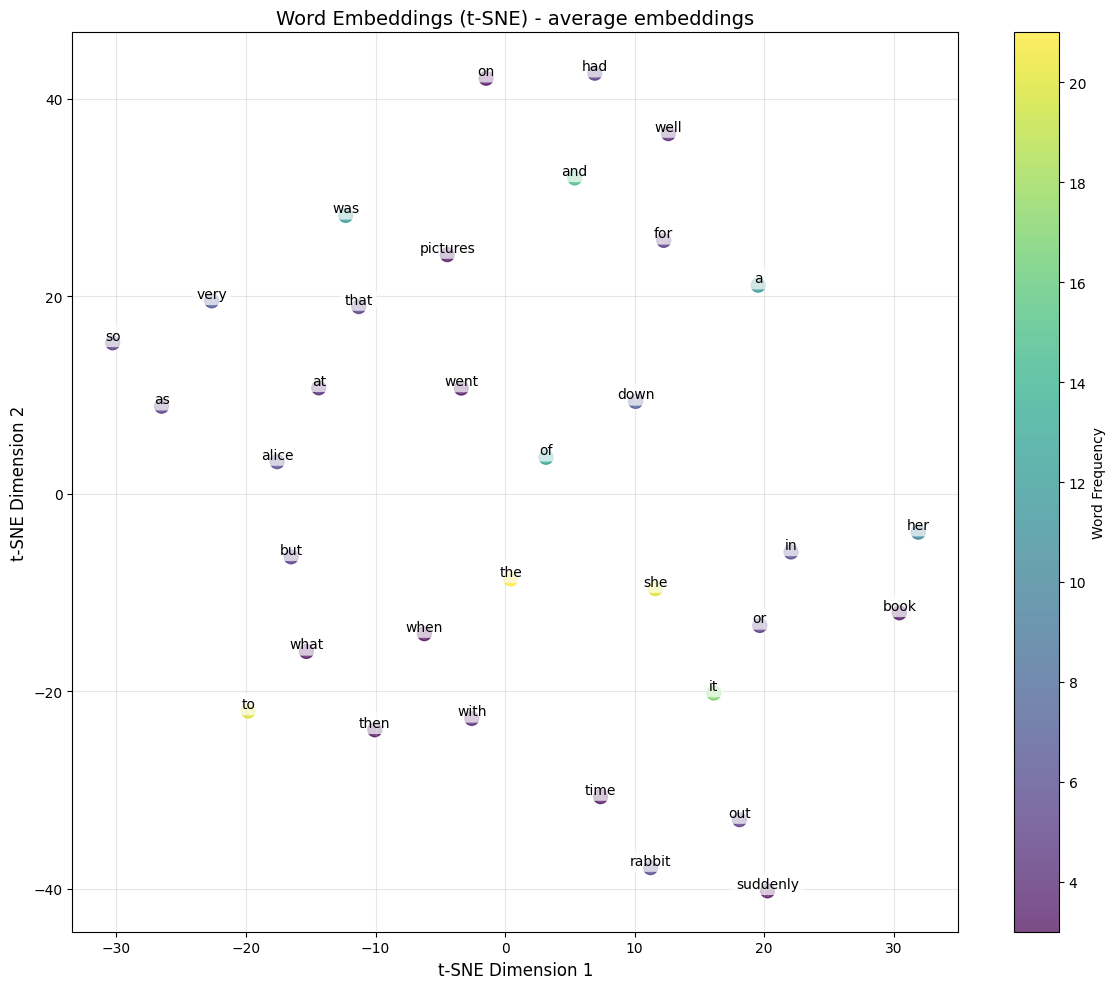

In [15]:
from sklearn.manifold import TSNE

def visualize_embeddings(model, word2idx, idx2word, method='average', 
                         min_freq=3, word_counts=None):
    """Visualize word embeddings using t-SNE."""
    
    # Filter words by frequency if word_counts provided
    if word_counts:
        words_to_plot = [w for w in word2idx.keys() if word_counts[w] >= min_freq]
    else:
        words_to_plot = list(word2idx.keys())
    
    # Get embeddings
    embeddings = []
    for word in words_to_plot:
        emb = model.get_embedding(word, word2idx, combine=method)
        embeddings.append(emb)
    
    embeddings = np.array(embeddings)
    
    # Reduce to 2D using t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(words_to_plot)-1))
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 10))
    
    # Color points by frequency (optional)
    if word_counts:
        frequencies = [word_counts[w] for w in words_to_plot]
        scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                             c=frequencies, cmap='viridis', alpha=0.7, s=100)
        plt.colorbar(scatter, label='Word Frequency')
    else:
        plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=100)
    
    # Add labels
    for i, word in enumerate(words_to_plot):
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                    fontsize=10, ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                             alpha=0.7, edgecolor='none'))
    
    plt.title(f'Word Embeddings (t-SNE) - {method} embeddings', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return embeddings_2d, words_to_plot

# Visualize
embeddings_2d, plotted_words = visualize_embeddings(
    model, word2idx, idx2word, 
    method='average',
    min_freq=3,
    word_counts=word_counts
)

### Complete Comparison: Center vs Context vs Average Embeddings

In [16]:
# ============================================
# COMPARE DIFFERENT EMBEDDING TYPES
# ============================================

print("="*60)
print("COMPARING EMBEDDING TYPES")
print("="*60)

word = "rabbit"
print(f"\nEmbeddings for '{word}':")
print(f"  Center (W1):    {model.get_center_embedding(word, word2idx)[:5]}...")
print(f"  Context (W2):   {model.get_context_embedding(word, word2idx)[:5]}...")
print(f"  Average:        {model.get_embedding(word, word2idx, 'average')[:5]}...")

# Compare similarities using different embedding types
print(f"\nSimilar words to 'rabbit' using different embeddings:")
print("-" * 50)

for method in ['center', 'context', 'average']:
    print(f"\n{method.upper()} embeddings:")
    similar = model.most_similar('rabbit', word2idx, idx2word, topn=5, combine=method)
    for w, sim in similar:
        print(f"  {w:15} {sim:.4f}")

COMPARING EMBEDDING TYPES

Embeddings for 'rabbit':
  Center (W1):    [ 0.17506939 -0.09760884 -0.2675734   0.31602831  0.58567455]...
  Context (W2):   [-0.046      -0.3125371  -0.07924378  0.55977444  0.59415106]...
  Average:        [ 0.0645347  -0.20507297 -0.17340859  0.43790138  0.5899128 ]...

Similar words to 'rabbit' using different embeddings:
--------------------------------------------------

CENTER embeddings:
  considering     0.7573
  out             0.6121
  down            0.5346
  suddenly        0.4634
  when            0.4090

CONTEXT embeddings:
  considering     0.7864
  out             0.6040
  down            0.5240
  it              0.4718
  suddenly        0.4521

AVERAGE embeddings:
  out             0.9535
  time            0.8861
  considering     0.8756
  suddenly        0.8727
  it              0.5566


### Saving and Loading the Model

In [17]:
import pickle

def save_model(model, filepath):
    """Save the trained model to a file."""
    with open(filepath, 'wb') as f:
        pickle.dump({
            'W1': model.W1,
            'W2': model.W2,
            'vocab_size': model.vocab_size,
            'embedding_dim': model.embedding_dim,
            'loss_history': model.loss_history
        }, f)
    print(f"Model saved to {filepath}")

def load_model(filepath):
    """Load a trained model from a file."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    model = SkipGramModel(data['vocab_size'], data['embedding_dim'])
    model.W1 = data['W1']
    model.W2 = data['W2']
    model.loss_history = data['loss_history']
    print(f"Model loaded from {filepath}")
    return model

# Save the model
save_model(model, 'skipgram_model.pkl')

# Load the model
loaded_model = load_model('skipgram_model.pkl')

Model saved to skipgram_model.pkl
Model loaded from skipgram_model.pkl


---
## Summary: What We've Implemented

In [18]:
print("="*70)
print("SKIP-GRAM WORD2VEC IMPLEMENTATION SUMMARY")
print("="*70)

summary = """
ARCHITECTURE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Input (one-hot, V)  →  W₁ (V×d)  →  h (d)  →  W₂ (d×V)  →  Softmax (V)
    
    • W₁: Center word embeddings (what we primarily use)
    • W₂: Context word embeddings (used during training)
    • h: Hidden representation = row of W₁ for center word
    • Output: Probability distribution over vocabulary

KEY EQUATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Forward:   P(o|c) = softmax(W₂ · W₁[c])
    
    Loss:      L = -log P(o|c)
    
    Gradients: 
        ∂L/∂W₁[c] = W₂ᵀ · (ŷ - y)
        ∂L/∂W₂    = (ŷ - y) ⊗ h
    
    Where:
        • c = center word index
        • o = context word index  
        • ŷ = predicted distribution
        • y = one-hot for true context word

TRAINING PROCESS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    1. For each (center, context) pair:
       a. Forward pass: compute P(context | center)
       b. Compute loss: -log P(context | center)
       c. Backward pass: compute gradients
       d. Update: W ← W - α · gradient
    
    2. Repeat for all pairs (one epoch)
    3. Repeat for multiple epochs

LIMITATIONS OF THIS IMPLEMENTATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Uses full softmax (O(V) per sample) - slow for large vocabularies
    • No negative sampling (would reduce to O(k) where k ≈ 5-20)
    • Small corpus → limited quality embeddings
    • No subsampling of frequent words
    • No learning rate decay

IN PRACTICE (Gensim/Original Word2Vec):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Negative sampling for efficiency
    • Subsampling of frequent words (the, a, is, ...)
    • Learning rate linearly decreases during training
    • Trained on billions of words
    • Vector dimensions: 100-300 typically
"""

print(summary)
print("="*70)

SKIP-GRAM WORD2VEC IMPLEMENTATION SUMMARY

ARCHITECTURE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Input (one-hot, V)  →  W₁ (V×d)  →  h (d)  →  W₂ (d×V)  →  Softmax (V)
    
    • W₁: Center word embeddings (what we primarily use)
    • W₂: Context word embeddings (used during training)
    • h: Hidden representation = row of W₁ for center word
    • Output: Probability distribution over vocabulary

KEY EQUATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Forward:   P(o|c) = softmax(W₂ · W₁[c])
    
    Loss:      L = -log P(o|c)
    
    Gradients: 
        ∂L/∂W₁[c] = W₂ᵀ · (ŷ - y)
        ∂L/∂W₂    = (ŷ - y) ⊗ h
    
    Where:
        • c = center word index
        • o = context word index  
        • ŷ = predicted distribution
        • y = one-hot for true context word

TRAINING PROCESS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    1. For each (center, context) pair:
       a. 